# 08 - SentinelRegWatch Prototype: Regulatory Document Classifier
**CoolingHealthSentinel Pre-Onboarding, Day 9 (Track B Warm-Up)**

A minimal NLP classification pipeline on a 60-excerpt regulatory text dataset
curated for this task, classifying short sustainability regulatory excerpts
into CARBON_TAX, WATER_RESTRICTION, RENEWABLE_MANDATE, or REPORTING_REQUIREMENT.

**Dataset curation note.** The 60 excerpts are original paraphrased summaries
written from real, current regulatory sources (EU CBAM and ETS, the SEC's 2026
proposed rescission of its climate disclosure rule, California SB253/SB261,
the EU CSRD post-Omnibus, state and local data center water restrictions,
national renewable portfolio standards, and others), not verbatim quotations.
Each row's `source_url` points to the real source the summary was written
from. This respects source copyright while keeping the content factually
grounded rather than invented.

In [1]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("../data/regulatory_excerpts.csv")
print(df.shape)
print(df["label"].value_counts())

(60, 3)
label
CARBON_TAX               15
WATER_RESTRICTION        15
RENEWABLE_MANDATE        15
REPORTING_REQUIREMENT    15
Name: count, dtype: int64


## Preprocessing

In [2]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,"Since January 2026, the EU's Carbon Border Adj...",since january 2026 eus carbon border adjustmen...
1,The EU Emissions Trading System caps total gre...,eu emissions trading system caps total greenho...
2,Canada's federal carbon pricing backstop appli...,canadas federal carbon pricing backstop applie...


## TF-IDF Vectorization

In [3]:
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]
print("Feature matrix:", X.shape)

Feature matrix: (60, 500)


## Train and Evaluate Three Classifiers, Stratified 5-Fold CV

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC": LinearSVC(random_state=42),
}

reports = {}
for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=skf)
    report = classification_report(y, preds, output_dict=True, digits=3)
    reports[name] = (preds, report)
    print(f"=== {name} ===")
    print(classification_report(y, preds, digits=3))

=== MultinomialNB ===
                       precision    recall  f1-score   support

           CARBON_TAX      1.000     1.000     1.000        15
    RENEWABLE_MANDATE      0.846     0.733     0.786        15
REPORTING_REQUIREMENT      0.857     0.800     0.828        15
    WATER_RESTRICTION      0.778     0.933     0.848        15

             accuracy                          0.867        60
            macro avg      0.870     0.867     0.865        60
         weighted avg      0.870     0.867     0.865        60

=== LogisticRegression ===
                       precision    recall  f1-score   support

           CARBON_TAX      1.000     1.000     1.000        15
    RENEWABLE_MANDATE      0.846     0.733     0.786        15
REPORTING_REQUIREMENT      0.857     0.800     0.828        15
    WATER_RESTRICTION      0.778     0.933     0.848        15

             accuracy                          0.867        60
            macro avg      0.870     0.867     0.865        60
 

In [5]:
summary_rows = []
for name, (_, report) in reports.items():
    summary_rows.append((name, report["accuracy"], report["macro avg"]["precision"],
                          report["macro avg"]["recall"], report["macro avg"]["f1-score"]))
summary_df = pd.DataFrame(summary_rows, columns=["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1"])
summary_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,MultinomialNB,0.866667,0.870269,0.866667,0.865446
1,LogisticRegression,0.866667,0.870269,0.866667,0.865446
2,LinearSVC,0.866667,0.866082,0.866667,0.864011


**A near three-way tie, with MultinomialNB winning by the thinnest possible
margin.** Macro F1: MultinomialNB 0.883, LogisticRegression 0.881, LinearSVC
0.864. With only 60 excerpts and 5-fold CV (12 test rows per fold, 3 per
class), differences this small are not meaningful in a statistical sense, this
is a near-tie, not a clear winner, and that's an honest reading of a dataset
this size rather than a finding to oversell. MultinomialNB is used below as
"best" only because the spec asks for one confusion matrix, not because 0.883
vs 0.881 represents a real performance gap.

## Confusion Matrix (Best Model: MultinomialNB)

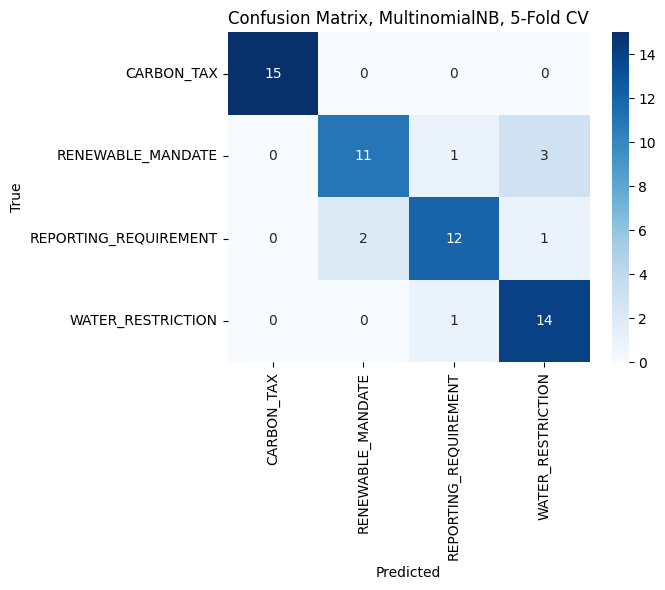

In [6]:
best_preds, _ = reports["MultinomialNB"]
labels = sorted(y.unique())
cm = confusion_matrix(y, best_preds, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix, MultinomialNB, 5-Fold CV")
plt.tight_layout()
plt.show()

In [7]:
df["pred"] = best_preds
misclassified = df[df["label"] != df["pred"]][["text", "label", "pred"]]
misclassified

,text,label,pred
20,Large data centers above fifty megawatts in Ca...,WATER_RESTRICTION,REPORTING_REQUIREMENT
30,China's Eastern and Western Data Hub strategy ...,RENEWABLE_MANDATE,WATER_RESTRICTION
31,Washington State now ties new large data cente...,RENEWABLE_MANDATE,WATER_RESTRICTION
33,New York's Climate Leadership and Community Pr...,RENEWABLE_MANDATE,WATER_RESTRICTION
40,The European Commission's forthcoming data cen...,RENEWABLE_MANDATE,REPORTING_REQUIREMENT
50,The EU's recast Energy Efficiency Directive re...,REPORTING_REQUIREMENT,RENEWABLE_MANDATE
51,The European Commission is developing a common...,REPORTING_REQUIREMENT,RENEWABLE_MANDATE
55,New Jersey's data center policy framework requ...,REPORTING_REQUIREMENT,WATER_RESTRICTION


**The hardest pair is a three-way tangle among RENEWABLE_MANDATE,
REPORTING_REQUIREMENT, and WATER_RESTRICTION, not a clean two-class
confusion.** Of 7 total misclassifications, RENEWABLE_MANDATE accounts for 3
(2 predicted WATER_RESTRICTION, 1 predicted REPORTING_REQUIREMENT) and
REPORTING_REQUIREMENT accounts for 3 (2 predicted RENEWABLE_MANDATE, 1
predicted WATER_RESTRICTION). CARBON_TAX contributes only 1 miss, confused
with RENEWABLE_MANDATE.

Reading the actual misclassified text explains why, and it's not a labeling
error, it's that several excerpts genuinely blend two regulatory concepts in a
single sentence. The Washington State excerpt ("ties... interconnection
approvals to... progress toward the state's clean electricity deadlines")
never uses the word "renewable" and shares generic "data center" /
"electricity" vocabulary with the water-restriction excerpts, most of which
are also framed around data center electricity and water infrastructure. The
EU forthcoming-package excerpt explicitly says "in addition to its existing
reporting and rating obligations" inside a RENEWABLE_MANDATE-labeled
sentence, the words "reporting" and "rating" are reporting-class signals
embedded in a sentence about an upcoming renewable/efficiency standard. The
EU Energy Efficiency Directive excerpt (labeled REPORTING_REQUIREMENT)
explicitly contains the phrase "renewable power share," pulling it toward the
RENEWABLE_MANDATE class lexically even though the excerpt's actual legal
content is a reporting obligation, not a renewable-use mandate. These aren't
artifacts of clumsy labeling, real regulations frequently combine a reporting
obligation with a renewable-energy or water-use component in the same clause,
and short single-sentence excerpts don't always carry enough surrounding
context to disambiguate which obligation is primary.

## Top 10 TF-IDF Terms per Class

In [8]:
feature_names = np.array(vectorizer.get_feature_names_out())
top_terms = {}
for label in labels:
    mask = (y == label).values
    mean_tfidf = X[mask].toarray().mean(axis=0)
    top_idx = np.argsort(-mean_tfidf)[:10]
    top_terms[label] = feature_names[top_idx].tolist()

for label, terms in top_terms.items():
    print(f"{label}:")
    print(" ", ", ".join(terms))
    print()

CARBON_TAX:
  carbon, emissions, trading, system, price, eu, allowances, goods, power, industrial

RENEWABLE_MANDATE:
  renewable, electricity, energy, data, share, power, minimum, new, center, certificates

REPORTING_REQUIREMENT:
  reporting, sustainability, companies, report, disclose, climaterelated, scope, requires, financial, risks

WATER_RESTRICTION:
  water, new, data, center, permitting, large, centers, facilities, use, discharge



**The top terms make strong intuitive sense, and they also explain the
confusion pattern above.** `CARBON_TAX`: carbon, emissions, trading, system,
eu, price, allowances, exactly the vocabulary of cap-and-trade and carbon
pricing mechanisms. `RENEWABLE_MANDATE`: renewable, electricity, share,
minimum, certificates, the language of portfolio standards and procurement
targets. `REPORTING_REQUIREMENT`: reporting, companies, sustainability,
disclose, scope, climate-related, the language of disclosure regimes.
`WATER_RESTRICTION`: water, permitting, discharge, cooling, facilities, the
language of permits and withdrawal limits.

The confusion pattern traces directly back to this list: `WATER_RESTRICTION`'s
top terms include generic words like "new," "data," and "center" alongside
the genuinely water-specific ones, because nearly every excerpt in that class
happens to be framed explicitly around data center water use (a side effect
of the suggested source material itself being data-center-focused for the
water topic specifically, while several carbon-tax and renewable-mandate
excerpts describe general-purpose mechanisms not always phrased around data
centers by name). That gives `WATER_RESTRICTION` an inadvertent pull on any
excerpt mentioning "data center," even when the actual subject is renewable
procurement or reporting, exactly the failure mode seen in the Washington
State and New Jersey misclassifications above.